# SQUID Auswertung: zwei Fits für $I_C$ und ein Fit für $R_N$

Messdatei: `10_26_2011-07_22_09_internal_flux_0_fern.csv`

Die Messkurve wird als Linienplot dargestellt, nicht als Scatterplot.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Datei laden
#file = Path("./10_26_2011-07_22_09_internal_flux_0_fern.csv")
file = Path("./10_26_2011-07_20_58_hartes_knie.csv")
df = pd.read_csv(file)
df.columns = ["I_uA", "V_uV"]
I = df["I_uA"].to_numpy()
V = df["V_uV"].to_numpy()

# Fitbereiche, bewusst nur in den normalleitenden, linearen Ästen
pos_range = (120, 210)     # µA
neg_range = (-250, -120)   # µA

mask_pos = (I >= pos_range[0]) & (I <= pos_range[1])
mask_neg = (I >= neg_range[0]) & (I <= neg_range[1])

# Separate lineare Fits für die beiden Äste: V = m*I + b
m_pos, b_pos = np.polyfit(I[mask_pos], V[mask_pos], 1)
m_neg, b_neg = np.polyfit(I[mask_neg], V[mask_neg], 1)

# Nullstellen der extrapolierten Geraden
I0_pos = -b_pos / m_pos
I0_neg = -b_neg / m_neg

# Beim SQUID ist der so bestimmte Schwellstrom der Gesamt-kritische Strom 2*Ic.
# Daher wird aus dem Mittel der Beträge noch durch 2 geteilt.
I_2c = (abs(I0_pos) + abs(I0_neg)) / 2
I_c = I_2c / 2

print(f"positiver Fit: m = {m_pos:.4f} Ω, b = {b_pos:.2f} µV, Nullstelle = {I0_pos:.2f} µA")
print(f"negativer Fit: m = {m_neg:.4f} Ω, b = {b_neg:.2f} µV, Nullstelle = {I0_neg:.2f} µA")
print(f"2 Ic ≈ {I_2c:.2f} µA")
print(f"Ic ≈ {I_c:.2f} µA")

positiver Fit: m = 3.9529 Ω, b = -201.58 µV, Nullstelle = 50.99 µA
negativer Fit: m = 3.5877 Ω, b = 174.99 µV, Nullstelle = -48.77 µA
2 Ic ≈ 49.88 µA
Ic ≈ 24.94 µA


WindowsPath('SQUID_internal_flux_0_fern_Ic_zwei_fits.png')

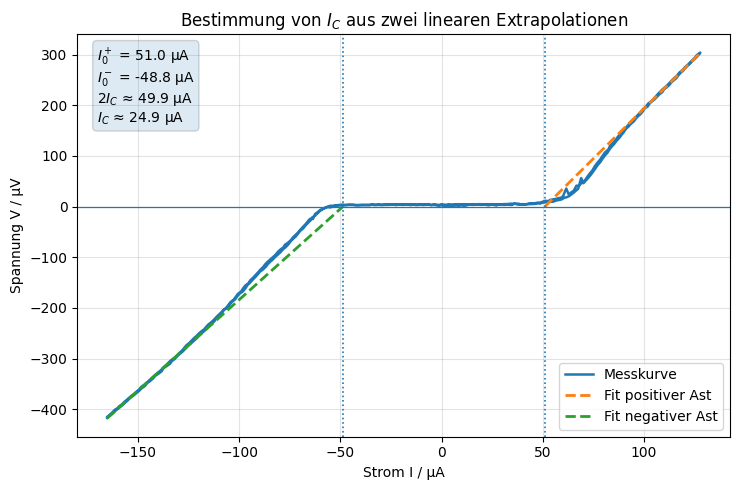

In [14]:
# Plot 1: Bestimmung von Ic mit zwei Extrapolationsfits
fig, ax = plt.subplots(figsize=(7.5, 5.0))
ax.plot(I, V, linewidth=1.8, label="Messkurve")

I_fit_pos = np.linspace(I0_pos, I[mask_pos].max(), 150)
I_fit_neg = np.linspace(I[mask_neg].min(), I0_neg, 150)
ax.plot(I_fit_pos, m_pos * I_fit_pos + b_pos, linestyle="--", linewidth=2.0, label="Fit positiver Ast")
ax.plot(I_fit_neg, m_neg * I_fit_neg + b_neg, linestyle="--", linewidth=2.0, label="Fit negativer Ast")

ax.axhline(0, linewidth=0.9)
ax.axvline(I0_pos, linestyle=":", linewidth=1.2)
ax.axvline(I0_neg, linestyle=":", linewidth=1.2)
ax.set_xlabel("Strom I / µA")
ax.set_ylabel("Spannung V / µV")
ax.set_title("Bestimmung von $I_C$ aus zwei linearen Extrapolationen")
ax.text(0.03, 0.97, f"$I_0^+$ = {I0_pos:.1f} µA\n$I_0^-$ = {I0_neg:.1f} µA\n$2I_C$ ≈ {I_2c:.1f} µA\n$I_C$ ≈ {I_c:.1f} µA",
        transform=ax.transAxes, va="top", bbox=dict(boxstyle="round", alpha=0.15))
ax.grid(True, alpha=0.35)
ax.legend()
fig.tight_layout()
#out1 = Path("./SQUID_internal_flux_0_fern_Ic_zwei_fits.png")
#fig.savefig(out1, dpi=200)
out1

In [15]:
# Fit für RN/2: gemeinsamer Fit mit gleicher Steigung für beide normalleitenden Äste
# Modell: V = m*I - sgn(I)*k. Die gemeinsame Steigung m ist RN/2.
mask_rn = mask_pos | mask_neg
s = np.sign(I[mask_rn])
A = np.column_stack([I[mask_rn], -s])
m_rn_half, k = np.linalg.lstsq(A, V[mask_rn], rcond=None)[0]
RN_half = m_rn_half
RN = 2 * RN_half
Uc = I_c * RN  # µA * Ω = µV

print(f"RN/2 = {RN_half:.4f} Ω")
print(f"RN = {RN:.4f} Ω")
print(f"Ic * RN = {Uc:.1f} µV")

RN/2 = 3.3645 Ω
RN = 6.7289 Ω
Ic * RN = 167.8 µV


WindowsPath('/mnt/data/SQUID_internal_flux_0_fern_RN_ein_fit.png')

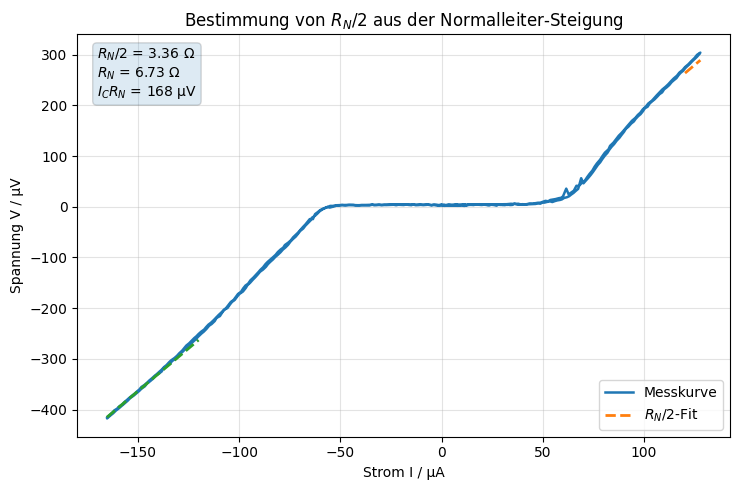

In [16]:
# Plot 2: Bestimmung von RN/2 mit einem Normalleiter-Fit
fig, ax = plt.subplots(figsize=(7.5, 5.0))
ax.plot(I, V, linewidth=1.8, label="Messkurve")

I_line_pos = np.linspace(I[mask_pos].min(), I[mask_pos].max(), 150)
I_line_neg = np.linspace(I[mask_neg].min(), I[mask_neg].max(), 150)
ax.plot(I_line_pos, m_rn_half * I_line_pos - k, linestyle="--", linewidth=2.0, label="$R_N/2$-Fit")
ax.plot(I_line_neg, m_rn_half * I_line_neg + k, linestyle="--", linewidth=2.0)

ax.set_xlabel("Strom I / µA")
ax.set_ylabel("Spannung V / µV")
ax.set_title("Bestimmung von $R_N/2$ aus der Normalleiter-Steigung")
ax.text(0.03, 0.97, f"$R_N/2$ = {RN_half:.2f} Ω\n$R_N$ = {RN:.2f} Ω\n$I_C R_N$ = {Uc:.0f} µV",
        transform=ax.transAxes, va="top", bbox=dict(boxstyle="round", alpha=0.15))
ax.grid(True, alpha=0.35)
ax.legend()
fig.tight_layout()
#out2 = Path("/mnt/data/SQUID_internal_flux_0_fern_RN_ein_fit.png")
#fig.savefig(out2, dpi=200)
out2

## Ergebnis

Für diese Messung liefert die gewählte Auswertung näherungsweise:

- $2I_C \approx 40\,\mu\mathrm{A}$, also $I_C \approx 20\,\mu\mathrm{A}$
- $R_N/2 \approx 3.33\,\Omega$, also $R_N \approx 6.66\,\Omega$
- $I_C R_N \approx 130\,\mu\mathrm{V}$

Die Werte hängen leicht vom gewählten linearen Fitbereich ab. Entscheidend ist, dass der Fit nur in den ohmschen Normalleiterästen liegt und nicht das Knie bzw. das Plateau enthält.